In [377]:
import numpy as np
import pandas as pd
import plotly.express as px
import collections
import itertools
import tqdm
from copy import deepcopy
from functools import lru_cache
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

In [378]:
np.random.seed(0)

In [379]:
def normalize_priors(priors):
    if np.sum(priors) == 0:
        return np.zeros_like(priors)
    return priors / np.sum(priors)

In [380]:
def best_response_vectorized(X, thresholds, priors, c):
    posteriors = normalize_priors(priors)
    utilities_expected = np.array([
        np.dot(posteriors, thresholds[j] >= thresholds)
        for j in range(len(thresholds))
    ])

    pass_matrix = X[:, None] >= thresholds[None, :]
    utility_stay = pass_matrix @ posteriors

    X_col = X[:, None]
    thresholds_row = thresholds[None, :]

    feasible = thresholds_row > X_col
    utility_jump = utilities_expected[None, :] - c * np.abs(thresholds_row - X_col)
    utility_jump[~feasible] = -np.inf

    utilities = np.concatenate([utility_stay[:, None], utility_jump],axis=1)

    best_idx = np.argmax(utilities, axis=1)
    X_p = np.where(best_idx == 0, X, thresholds[best_idx - 1])

    return X_p

In [381]:
def accuracy_loss_vectorized(X, X_p, thresholds, priors, threshold_true):
    Y_true = (X >= threshold_true).astype(float)
    Y_p = (X_p[:, None] >= thresholds[None, :]).astype(float)
    losses = np.abs(Y_true[:, None] - Y_p).mean(axis=0)
    posteriors = normalize_priors(priors)
    return np.dot(losses, posteriors)

In [382]:
def evaluate_partition(X, partition, thresholds, priors, threshold_true, c, return_all=False):
    thresholds_p = thresholds[partition]
    priors_p = priors[partition]
    X_p = best_response_vectorized(X, thresholds_p, priors_p, c)
    acc_loss_p = accuracy_loss_vectorized(X, X_p, thresholds_p, priors_p, threshold_true)
    if return_all:
        return acc_loss_p, thresholds_p, priors_p
    return acc_loss_p

def evaluate_system(X, partitions, thresholds, priors, threshold_true, c):
    acc_loss = 0.
    for partition in partitions:
        acc_loss_p = evaluate_partition(X, partition, thresholds, priors, threshold_true, c)
        acc_loss += acc_loss_p * np.sum(priors[partition])
    return acc_loss

In [383]:
def set_partitions(collection):
    if len(collection) == 1:
        yield [collection]
        return

    first = collection[0]
    for smaller in set_partitions(collection[1:]):
        for i in range(len(smaller)):
            yield smaller[:i] + [[first] + smaller[i]] + smaller[i+1:]
        yield [[first]] + smaller

In [384]:
def find_partitions_optimal(X, thresholds, priors, threshold_true, c):
    indices = list(range(len(thresholds)))
    partitions_set = list(set_partitions(indices))

    @lru_cache(maxsize=None)
    def evaluate_partition_cached(partition_tuple):
        partition = list(partition_tuple)
        acc_loss_p = evaluate_partition(
            X, partition, thresholds, priors, threshold_true, c
        )
        return acc_loss_p * np.sum(priors[partition])

    best_partition = None
    best_loss = np.inf

    for partitions in partitions_set:
        acc_loss = 0.0
        for partition in partitions:
            partition_tuple = tuple(sorted(partition))
            acc_loss += evaluate_partition_cached(partition_tuple)

        if acc_loss < best_loss:
            best_loss = acc_loss
            best_partition = deepcopy(partitions)

    return best_partition

In [395]:
def display_queue(Q, P):
    res = "Q: [  "
    for (a_id, b_id) in Q:
        res += f"({P[a_id]}, {P[b_id]})  "
    res += "]"
    print(res)

def find_partitions_greedy(X, thresholds, priors, threshold_true, c, display=False):
    P = {}
    next_id = 0
    partitions = [[i] for i in range(len(priors))]
    for block in partitions:
        P[next_id] = list(block)
        next_id += 1


    Q = collections.deque(itertools.combinations(P.keys(), 2))

    while Q:
        if display:
            display_queue(Q, P)
        a_id, b_id = Q.popleft()
        if a_id not in P.keys() or b_id not in P.keys():
            continue

        a = P[a_id]
        b = P[b_id]

        acc_loss_a = evaluate_partition(X, a, thresholds, priors, threshold_true, c)
        acc_loss_b = evaluate_partition(X, b, thresholds, priors, threshold_true, c)
        lhs = acc_loss_a * np.sum(priors[a]) + acc_loss_b * np.sum(priors[b])

        ab = sorted(a + b)
        acc_loss_ab = evaluate_partition(X, ab, thresholds, priors, threshold_true, c)
        rhs = acc_loss_ab * np.sum(priors[ab])

        # if lhs - rhs > -1e-6:
        if lhs > rhs:
            if display:
                print(f"Merging {a} and {b}\n")
            del P[a_id]
            del P[b_id]

            Q = collections.deque(
                (x, y)
                for (x, y) in Q
                if x not in {a_id, b_id} and y not in {a_id, b_id}
            )

            new_id = next_id
            next_id += 1
            P[new_id] = ab

            for c_id in P.keys():
                if c_id != new_id:
                    Q.append((new_id, c_id))

            # Q = collections.deque(sorted(Q, key=lambda x: P[x[0]]))
    return list(P.values())

In [386]:
def approximation_ratio(loss_optimal, loss_greedy):
    if (1 - loss_greedy) == 0:
        return np.nan
    return (loss_greedy) / (loss_optimal)

In [387]:
x_min, x_max, x_disc = 0., 1., 1e-4
X = np.arange(x_min, x_max+x_disc, x_disc).round(4)
N_REPS = 100
N_THRESHOLDS = 6

In [388]:
np.random.seed(42)

def sweep(param_name, param_values, n_reps=N_REPS):
    means, stds = [], []
    d = {"thresholds": [], "priors": [], "t*": [], "c": [], "partition_opt": [], "partition_greedy": [], "loss_opt": [], "loss_greedy": [], "r": []}
    for val in param_values:
        reps = []
        for _ in range(n_reps):
            thresholds_base = np.sort(np.random.uniform(1e-9, 1, N_THRESHOLDS))
            priors_base = np.ones(N_THRESHOLDS) / N_THRESHOLDS
            threshold_true_base = np.median(thresholds_base)
            c_base = 0.999999
            if param_name == 'c':
                thresholds = thresholds_base
                priors = priors_base
                threshold_true = threshold_true_base
                c = val
            elif param_name == 'alpha':
                thresholds = thresholds_base
                priors = np.random.dirichlet([val] * N_THRESHOLDS)
                threshold_true = threshold_true_base
                c = c_base
            elif param_name == 'tt':
                thresholds = thresholds_base
                priors = priors_base
                if val > 1:
                    threshold_true = 0.999999
                elif val < 0:
                    threshold_true = 1e-9
                else:
                    threshold_true = thresholds.min() + val * (thresholds.max() - thresholds.min())
                c = c_base
            elif param_name == 'gap':
                half = N_THRESHOLDS // 2
                c1 = np.random.uniform(1e-9, 0.25, half)
                c2 = np.random.uniform(0.25 + val, np.minimum(0.4 + val, 1), N_THRESHOLDS - half)
                thresholds = np.sort(np.concatenate([c1, c2]))
                priors = priors_base
                threshold_true = np.median(thresholds)
                c = c_base
            
            partition_opt = find_partitions_optimal(X, thresholds, priors, threshold_true, c)
            partition_greedy = find_partitions_greedy(X, thresholds, priors, threshold_true, c)
            loss_opt = evaluate_system(X, partition_opt, thresholds, priors, threshold_true, c)
            loss_greedy = evaluate_system(X, partition_greedy, thresholds, priors, threshold_true, c)
            r  = approximation_ratio(loss_opt, loss_greedy)
            if not np.isnan(r):
                d["thresholds"].append(thresholds)
                d["priors"].append(priors)
                d["t*"].append(threshold_true)
                d["c"].append(c)
                d["partition_opt"].append(partition_opt)
                d["partition_greedy"].append(partition_greedy)
                d["loss_opt"].append(loss_opt.item())
                d["loss_greedy"].append(loss_greedy.item())
                d["r"].append(r.item())
                reps.append(r)
        
        means.append(float(np.max(reps)) if reps else None)
        stds.append(float(np.std(reps))   if reps else None)

    return d, np.array(means), np.array(stds)

In [389]:
c_values     = [0.01, 0.025, 0.05, 0.075, 0.1, 0.25, 0.5, 0.75, 1.0, 5.0]
alpha_values = [0.1, 0.3, 0.5, 1.0, 2.0, 5.0, 10.0]
tt_quantiles = [0.0, 0.1, 0.25, 0.5, 0.75, 0.9, 1.0, 1.1]
gap_values   = [0.0, 0.05, 0.1, 0.2, 0.3, 0.5, 0.8]

d_c, r_c, s_c = sweep('c',     c_values)
d_a, r_a, s_a = sweep('alpha', alpha_values)
d_tt, r_tt, s_tt = sweep('tt',    tt_quantiles)
# d_gap = sweep('gap',   gap_values)

In [401]:
i = np.argmax(d_tt["r"])

thresholds = d_tt["thresholds"][i]
priors = d_tt["priors"][i]
threshold_true = d_tt["t*"][i]
c = d_tt["c"][i]

partition_opt = d_tt["partition_opt"][i]
# partition_greedy = d_tt["partition_greedy"][i]
partition_greedy = find_partitions_greedy(X, thresholds, priors, threshold_true, c)

loss_opt = d_tt["loss_opt"][i]
# loss_greedy = d_tt["loss_greedy"][i]
loss_greedy = evaluate_system(X, partition_greedy, thresholds, priors, threshold_true, c)

r = approximation_ratio(loss_opt, loss_greedy)

In [404]:
display(pd.DataFrame({"Thresholds": d_tt["thresholds"][i], "Priors": d_tt["priors"][i]}).round(6).T)
print(f"c              : {c}")
print(f"t*             : {d_tt['t*'][i]:.4f}")
print()
print("Greedy")
print("------")
print(f"Partition      : {partition_greedy}")
print(f"Accuracy loss  : {loss_greedy:.6f}")
print()
print("Optimal")
print("-------")
print(f"Partition      : {partition_opt}")
print(f"Accuracy loss  : {loss_opt:.6f}")
print()
print(f"r (mult)       : {approximation_ratio(loss_opt, loss_greedy):.4f}")
print("-"*80)
print()

,0,1,2,3,4,5
Thresholds,0.151134,0.329276,0.497727,0.580567,0.839403,0.951406
Priors,0.166667,0.166667,0.166667,0.166667,0.166667,0.166667


c              : 0.999999
t*             : 0.1511

Greedy
------
Partition      : [[0], [1], [2], [3], [4], [5]]
Accuracy loss  : 0.151185

Optimal
-------
Partition      : [[1], [0, 2, 3, 4, 5]]
Accuracy loss  : 0.050595

r (mult)       : 2.9881
--------------------------------------------------------------------------------



In [396]:
find_partitions_greedy(X, thresholds, priors, threshold_true, c, True)

Q: [  ([0], [1])  ([0], [2])  ([0], [3])  ([0], [4])  ([0], [5])  ([1], [2])  ([1], [3])  ([1], [4])  ([1], [5])  ([2], [3])  ([2], [4])  ([2], [5])  ([3], [4])  ([3], [5])  ([4], [5])  ]
Q: [  ([0], [2])  ([0], [3])  ([0], [4])  ([0], [5])  ([1], [2])  ([1], [3])  ([1], [4])  ([1], [5])  ([2], [3])  ([2], [4])  ([2], [5])  ([3], [4])  ([3], [5])  ([4], [5])  ]
Q: [  ([0], [3])  ([0], [4])  ([0], [5])  ([1], [2])  ([1], [3])  ([1], [4])  ([1], [5])  ([2], [3])  ([2], [4])  ([2], [5])  ([3], [4])  ([3], [5])  ([4], [5])  ]
Q: [  ([0], [4])  ([0], [5])  ([1], [2])  ([1], [3])  ([1], [4])  ([1], [5])  ([2], [3])  ([2], [4])  ([2], [5])  ([3], [4])  ([3], [5])  ([4], [5])  ]
Q: [  ([0], [5])  ([1], [2])  ([1], [3])  ([1], [4])  ([1], [5])  ([2], [3])  ([2], [4])  ([2], [5])  ([3], [4])  ([3], [5])  ([4], [5])  ]
Q: [  ([1], [2])  ([1], [3])  ([1], [4])  ([1], [5])  ([2], [3])  ([2], [4])  ([2], [5])  ([3], [4])  ([3], [5])  ([4], [5])  ]
Q: [  ([1], [3])  ([1], [4])  ([1], [5])  ([2], [3])

[[0], [1], [2], [3], [4], [5]]

In [403]:
a, b = [0,2,3,4,5], [1]

acc_loss_b, thresholds_b, priors_b = evaluate_partition(X, b, thresholds, priors, threshold_true, c, True)
acc_loss_a, thresholds_a, priors_a = evaluate_partition(X, a, thresholds, priors, threshold_true, c, True)

lhs = acc_loss_a * np.sum(priors[a]) + acc_loss_b * np.sum(priors[b])
ab = sorted(a + b)

acc_loss_ab, thresholds_ab, priors_ab = evaluate_partition(X, ab, thresholds, priors, threshold_true, c, True)
rhs = acc_loss_ab * np.sum(priors[ab])

print(f"    threshold true: {threshold_true:.4f}")
print(f"                 c: {c}")
print(f"                 a: {a}")
print(f"                 b: {b}")
print(f"   accuracy loss a: {acc_loss_a:.7f}")
print(f"   accuracy loss b: {acc_loss_b:.7f}")
print(f"  accuracy loss ab: {acc_loss_ab:.7f}")
print(f"               LHS: {lhs:.7f}")
print(f"               RHS: {rhs:.7f}")
print(f"            merge?: {lhs - rhs > 0}")
print()

# print(f"          priors a: {priors_a.round(4)}")
# print(f"      thresholds a: {thresholds_a.round(4)}")
# print(f"          priors b: {priors_b.round(4)}")
# print(f"      thresholds b: {thresholds_b.round(4)}")
# print(f"     thresholds ab: {thresholds_ab.round(4)}")
# print(f"         priors ab: {priors_ab.round(4)}")

    threshold true: 0.1511
                 c: 0.999999
                 a: [0, 2, 3, 4, 5]
                 b: [1]
   accuracy loss a: 0.0304770
   accuracy loss b: 0.1511849
  accuracy loss ab: 0.2564077
               LHS: 0.0505949
               RHS: 0.2564077
            merge?: False



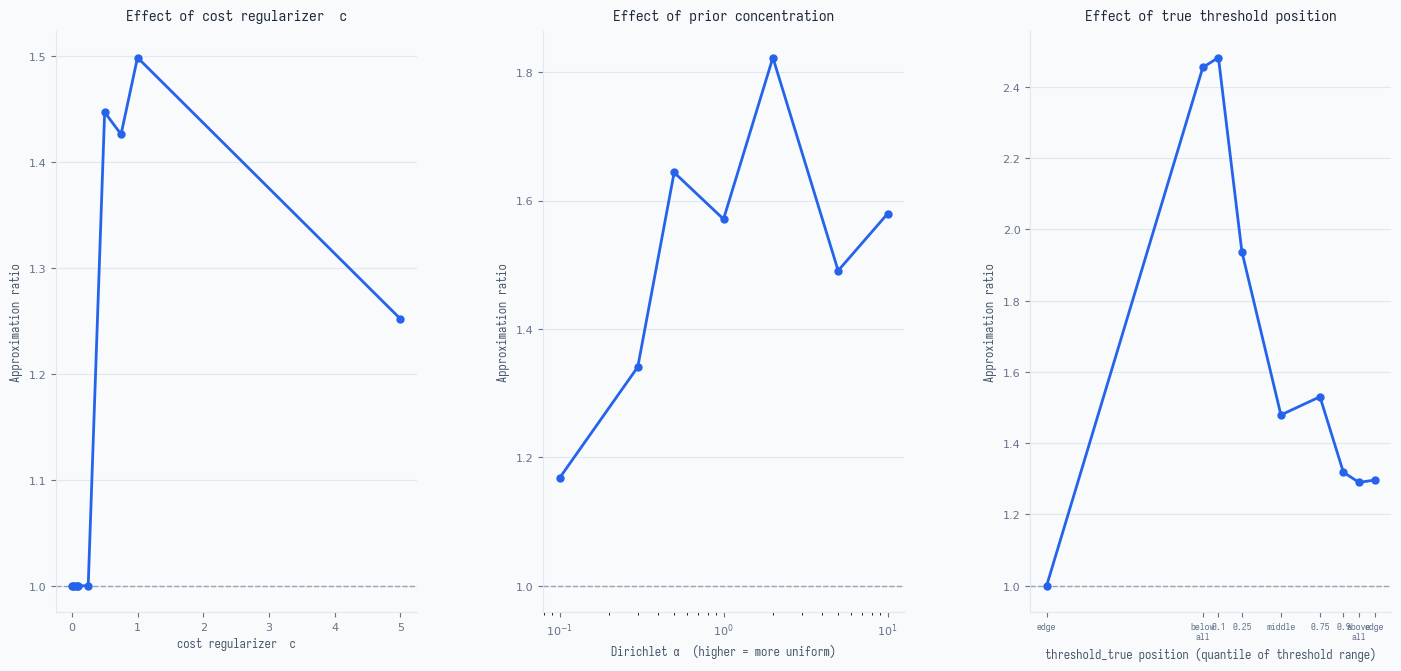

In [363]:
BLUE   = '#2563EB'
FILL   = '#BFDBFE'
BG     = '#F8FAFC'
GRID   = '#E2E8F0'


fig = plt.figure(figsize=(15, 7), facecolor=BG)
# fig.suptitle('Approximation Ratio',
#              fontfamily="iosevka", fontsize=14, fontweight='bold', y=1, color='#1E293B')

gs = gridspec.GridSpec(1, 3, wspace=0.35,
                       left=0.08, right=0.97, top=0.91, bottom=0.08)

def styled_ax(ax, title, xlabel):
    ax.set_facecolor(BG)
    ax.set_title(title, fontfamily="iosevka", fontsize=11, color='#1E293B', pad=8)
    ax.set_xlabel(xlabel, fontsize=9, color='#475569', fontfamily="iosevka")
    ax.set_ylabel('Approximation ratio', fontsize=9, color='#475569', fontfamily="iosevka")
    ax.tick_params(colors='#64748B', labelsize=8)
    ax.spines[['top','right']].set_visible(False)
    ax.spines[['left','bottom']].set_color(GRID)
    ax.yaxis.grid(True, color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)
    ax.axhline(1.0, color='#94A3B8', linewidth=1, linestyle='--', label='ratio = 1')

def plot_sweep(ax, xs, means, stds, xlabel, title, xlog=False, xlabels=None):
    styled_ax(ax, title, xlabel)
    ax.plot(xs, means, color=BLUE, linewidth=2, marker='o', markersize=5, zorder=3)
    # ax.fill_between(xs, np.maximum(means - stds, 1), means + stds, color=FILL, alpha=0.6, zorder=2)
    if xlog:
        ax.set_xscale('log')
    if xlabels:
        ax.set_xticks(xs)
        ax.set_xticklabels(xlabels, fontsize=7, fontfamily="iosevka")
    # ax.set_ylim(bottom=min(0.85, np.nanmin(means - stds) - 0.02))

# Plot 1 — cost c
ax1 = fig.add_subplot(gs[0, 0])
plot_sweep(ax1, c_values, r_c, s_c,
           'cost regularizer  c', 'Effect of cost regularizer  c', xlog=False)

# Plot 2 — prior concentration
ax2 = fig.add_subplot(gs[0, 1])
plot_sweep(ax2, alpha_values, r_a, s_a,
           'Dirichlet α  (higher = more uniform)', 'Effect of prior concentration', xlog=True)

# Plot 3 — threshold_true position
ax3 = fig.add_subplot(gs[0, 2])
plot_sweep(ax3, tt_quantiles, r_tt, s_tt,
           'threshold_true position (quantile of threshold range)',
           'Effect of true threshold position',
           xlabels=['edge', 'below\nall', '0.1', '0.25', 'middle', '0.75', '0.9', 'above\nall', 'edge'])

# # Plot 4 — cluster gap
# ax4 = fig.add_subplot(gs[1, 1])
# plot_sweep(ax4, gap_values, r_gap, s_gap,
#            'Gap between threshold clusters',
#            'Effect of threshold clustering')

# plt.savefig("../figures/effect_of_parameters_on_approximation_ratio.pdf")

array([1.5098664 , 1.71854602, 1.47849397, 1.27499085, 1.17988471,
       1.18317716, 1.1407004 , 1.12610922])